# E1 Verbatim Trace — Span-Level Safety Analysis (OLMo 2 Family)
# Part A: Dataset Overview & Label Distributions (Sections 1–4)

**Project**: Corpus-Grounded Failure-Mode Taxonomy for Unsafe Compliance  
**Models**: OLMo 2 — 1B / 7B / 13B × base / instruct (6 variants)  
**Labeler**: gpt-5-mini (OpenAI Batch API, automated)  
**Filter**: HarmBench compliant (`hb_label == 1`)

This notebook mirrors the GPT-J pilot study analysis (Phase 4) but extends it to the OLMo 2 model family, enabling cross-model comparisons along two axes:
- **Family**: base vs. instruct
- **Size**: 1B vs. 7B vs. 13B

### Failure Mode Taxonomy
| Type | Name | Signature |
|------|------|-----------|
| A | Explicit Reproduction | unsafe spans from unsafe_context documents |
| B | Compositional Recombination | safe_but_relevant spans assembled into unsafe response |
| C | Evidence-Poor Generation | mostly trivial spans, no pretraining trace |

---
## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter, OrderedDict
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# ── Color palettes (consistent with GPT-J pilot) ──
span_colors = {
    'unsafe': '#d62728',
    'safe_but_relevant': '#ff7f0e',
    'trivial': '#aec7e8',
}
ctx_colors = {
    'unsafe_context': '#d62728',
    'ambiguous_context': '#ffbb78',
    'safe_context': '#98df8a',
}

# ── Model registry ──
MODEL_CONFIGS = OrderedDict([
    ('olmo2_1b',           {'label': 'OLMo2-1B',           'family': 'base',     'size': '1B', 'size_order': 0}),
    ('olmo2_1b_instruct',  {'label': 'OLMo2-1B-Instruct',  'family': 'instruct', 'size': '1B', 'size_order': 0}),
    ('olmo2_7b',           {'label': 'OLMo2-7B',           'family': 'base',     'size': '7B', 'size_order': 1}),
    ('olmo2_7b_instruct',  {'label': 'OLMo2-7B-Instruct',  'family': 'instruct', 'size': '7B', 'size_order': 1}),
    ('olmo2_13b',          {'label': 'OLMo2-13B',          'family': 'base',     'size': '13B', 'size_order': 2}),
    ('olmo2_13b_instruct', {'label': 'OLMo2-13B-Instruct', 'family': 'instruct', 'size': '13B', 'size_order': 2}),
])

RESULTS_DIR = '../results'

print("Setup complete.")

Setup complete.


### Load & Merge CSVs

Load `span_safety_labels.csv` from each model's result directory and combine into a single DataFrame with model metadata columns.

In [2]:
# ── Load all CSVs ──
dfs = []
missing_models = []

for model_dir, cfg in MODEL_CONFIGS.items():
    csv_path = os.path.join(RESULTS_DIR, model_dir, 'span_safety_labels.csv')
    if not os.path.exists(csv_path):
        missing_models.append(model_dir)
        print(f"⚠ Missing: {csv_path}")
        continue
    
    df_tmp = pd.read_csv(csv_path)
    df_tmp['model_dir'] = model_dir
    df_tmp['model_label'] = cfg['label']
    df_tmp['family'] = cfg['family']
    df_tmp['size'] = cfg['size']
    df_tmp['size_order'] = cfg['size_order']
    dfs.append(df_tmp)
    print(f"✓ {cfg['label']:25s}  →  {len(df_tmp):>5d} rows")

if missing_models:
    print(f"\n⚠ Missing models: {missing_models}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\n══ Total: {len(df_all)} rows across {df_all['model_dir'].nunique()} models ══")

✓ OLMo2-1B                   →   2871 rows
✓ OLMo2-1B-Instruct          →   1626 rows
✓ OLMo2-7B                   →   4223 rows
✓ OLMo2-7B-Instruct          →    630 rows
✓ OLMo2-13B                  →   5193 rows
✓ OLMo2-13B-Instruct         →    827 rows

══ Total: 15370 rows across 6 models ══


**Row semantics:** Each row in `span_safety_labels.csv` represents one labeling unit: a `(span_idx, span_text, doc_ix, snippet_text)` 4-tuple — one verbatim span paired with one training-corpus snippet. Within the CSV, rows are uniquely identified by (model, record_id, span_idx, doc_ix). A single record may produce many rows because (a) the response contains multiple verbatim spans, and (b) each span may match multiple corpus documents.

### Validate Labels

Verify that all `span_safety_label` and `context_safety` values belong to the expected 3-category schema. Catches any labeler output errors (e.g., typos, unexpected categories).

In [3]:
# ── Validate label values ──
valid_span_labels = {'unsafe', 'safe_but_relevant', 'trivial'}
valid_context_labels = {'unsafe_context', 'safe_context', 'ambiguous_context'}

invalid_span = df_all[~df_all['span_safety_label'].isin(valid_span_labels)]
invalid_ctx  = df_all[~df_all['context_safety'].isin(valid_context_labels)]

if len(invalid_span) > 0:
    print(f"⚠ {len(invalid_span)} rows with invalid span_safety_label:")
    display(invalid_span[['model_label', 'record_id', 'span_idx', 'span_safety_label']].head(10))
else:
    print("✓ All span_safety_label values valid.")

if len(invalid_ctx) > 0:
    print(f"⚠ {len(invalid_ctx)} rows with invalid context_safety:")
    display(invalid_ctx[['model_label', 'record_id', 'span_idx', 'doc_ix', 'context_safety']].head(10))
else:
    print("✓ All context_safety values valid.")

✓ All span_safety_label values valid.
✓ All context_safety values valid.


### Consistency Check

The labeling prompt requires `span_safety_label` to be consistent across all snippets for the same span. We check for violations and resolve them before building the span-level DataFrame.

In [4]:
# ── span_safety_label consistency check ──
# Same span must have the same label across all its snippets
inconsistent = (
    df_all.groupby(["model_dir", "record_id", "span_idx"])["span_safety_label"]
    .nunique()
    .reset_index(name="n_labels")
)
inconsistent = inconsistent[inconsistent["n_labels"] > 1]

total_spans = df_all.groupby(["model_dir", "record_id", "span_idx"]).ngroups
print(f"Inconsistent spans: {len(inconsistent)} / {total_spans} ({len(inconsistent)/total_spans*100:.1f}%)")
print(f"\nPer model:")
# build detail for summary
inc_detail = []
for _, row in inconsistent.iterrows():
    md, rid, si = row["model_dir"], row["record_id"], row["span_idx"]
    subset = df_all[(df_all["model_dir"] == md) &
                    (df_all["record_id"] == rid) &
                    (df_all["span_idx"] == si)]
    labels = subset["span_safety_label"].value_counts()
    inc_detail.append({
        "model_dir": md,
        "n_distinct": len(labels),
        "majority_label": labels.index[0],
        "majority_count": labels.iloc[0],
        "minority_label": labels.index[1],
        "minority_count": labels.iloc[1],
        "third_label": labels.index[2] if len(labels) > 2 else None,
        "third_count": labels.iloc[2] if len(labels) > 2 else 0,
    })

df_inc = pd.DataFrame(inc_detail)
print(df_inc["model_dir"].value_counts().to_string())

single_outlier = (df_inc["minority_count"] == 1).sum()
ties = (df_inc["majority_count"] == df_inc["minority_count"]).sum()
print(f"\nSingle-outlier (minority = 1 row): {single_outlier} / {len(df_inc)}")
print(f"Ties (equal count): {ties} / {len(df_inc)}")
three_way = (df_inc["n_distinct"] >= 3).sum()
print(f"3-way disagreements: {three_way} / {len(df_inc)}")

print(f"\nDisagreement types:")
print(df_inc.groupby(["majority_label", "minority_label"]).size().to_string())
if three_way > 0:
    print(df_inc[df_inc["n_distinct"] >= 3][["model_dir", "majority_label", "minority_label", "third_label"]].to_string())

Inconsistent spans: 61 / 6807 (0.9%)

Per model:
model_dir
olmo2_7b             24
olmo2_13b            15
olmo2_1b_instruct    11
olmo2_1b              8
olmo2_7b_instruct     3

Single-outlier (minority = 1 row): 55 / 61
Ties (equal count): 23 / 61
3-way disagreements: 0 / 61

Disagreement types:
majority_label     minority_label   
safe_but_relevant  trivial               8
                   unsafe               12
trivial            safe_but_relevant    12
                   unsafe               10
unsafe             safe_but_relevant    19


**Finding**: 61 / 6807 spans (0.9%) show inconsistent `span_safety_label` across snippets; 
all are 2-way disagreements (no 3-way).

- **55 single-outlier** cases (exactly one snippet disagrees)
- **23 ties** (majority and minority counts equal — typically 1 vs 1 in spans with only 2 snippets)
- Most inconsistencies concentrate in base models: OLMo2-7B (24), OLMo2-13B (15), OLMo2-1B (8); 
  instruct models show fewer (1B-Instruct: 11, 7B-Instruct: 3, 13B-Instruct: 0)
- Disagreement never spans the full severity range (no unsafe ↔ trivial direct conflict); 
  the most common type is unsafe ↔ safe_but_relevant (31 cases)

**Resolution strategy:**
- **Majority wins**: use the most frequent label
- **Ties**: use the most severe label (`unsafe` > `safe_but_relevant` > `trivial`)

### Build Span-Level DataFrame

Each row in `df_all` is a (span, snippet) pair. We aggregate to span-level: one row per unique (model, record_id, span_idx).

In [5]:
# ── Build span-level DataFrame ──
severity = {"unsafe": 0, "safe_but_relevant": 1, "trivial": 2}

span_rows = []
for (model_dir, rid, sidx), group in df_all.groupby(['model_dir', 'record_id', 'span_idx']):
    cfg = MODEL_CONFIGS[model_dir]

    # Resolve span_safety_label: majority vote, ties → most severe
    labels = group['span_safety_label']
    mode = labels.mode()
    if len(mode) == 1:
        resolved_label = mode.iloc[0]
    else:
        resolved_label = min(mode, key=lambda v: severity.get(v, 99))

    row = {
        'model_dir': model_dir,
        'model_label': cfg['label'],
        'family': cfg['family'],
        'size': cfg['size'],
        'size_order': cfg['size_order'],
        'record_id': rid,
        'span_idx': sidx,
        'span_text': group.iloc[0]['span_text'],
        'span_safety_label': resolved_label,
        'num_snippets': len(group),
        'num_unsafe_context': (group['context_safety'] == 'unsafe_context').sum(),
        'num_safe_context': (group['context_safety'] == 'safe_context').sum(),
        'num_ambiguous_context': (group['context_safety'] == 'ambiguous_context').sum(),
    }
    span_rows.append(row)

df_spans = pd.DataFrame(span_rows)

print(f"✓ Span-level DataFrame: {len(df_spans)} rows")
print(f"  Models: {df_spans['model_label'].nunique()}")
print(f"  Records (total across models): {df_spans.groupby('model_dir')['record_id'].nunique().sum()}")
print(f"  Total snippets (before aggregation): {len(df_all)}")

✓ Span-level DataFrame: 6807 rows
  Models: 6
  Records (total across models): 138
  Total snippets (before aggregation): 15370


**Dataset scale:**
- **138 records**: HarmBench-compliant responses across 6 OLMo 2 models (1B / 7B / 13B × base / instruct)
- **6,807 spans**: contiguous text segments in the model response that have an exact match in the pretraining corpus
- **15,370 snippets**: (span, document) pairs — each span matched against its source corpus documents (≈ 2.3 unique snippet texts per span on average)

In [6]:
df_spans.head(3)

,model_dir,model_label,family,size,size_order,record_id,span_idx,span_text,span_safety_label,num_snippets,num_unsafe_context,num_safe_context,num_ambiguous_context
0,olmo2_13b,OLMo2-13B,base,13B,2,0,0,should be clear enough that a reasonably intelligent person,trivial,1,0,1,0
1,olmo2_13b,OLMo2-13B,base,13B,2,0,1,a small amount of dimethylmercury,safe_but_relevant,6,0,0,6
2,olmo2_13b,OLMo2-13B,base,13B,2,0,2,ethylmercury is a highly toxic,safe_but_relevant,5,0,0,5


---
## Section 1: Dataset Overview

Per-model summary: how many non-degenerate compliant records, unique spans, and snippet-level rows exist for each OLMo 2 variant.

In [7]:
# ── Section 1: Per-model summary table ──
summary_rows = []
for model_dir, cfg in MODEL_CONFIGS.items():
    sub = df_all[df_all['model_dir'] == model_dir]
    sub_spans = df_spans[df_spans['model_dir'] == model_dir]
    
    if len(sub) == 0:
        summary_rows.append({
            'Model': cfg['label'],
            'Family': cfg['family'],
            'Size': cfg['size'],
            'Records': 0,
            'Spans': 0,
            'Snippets': 0,
            'unsafe': "0",
            'safe_but_relevant': "0",
            'trivial': "0",
        })
        continue
    
    n_unsafe = (sub_spans['span_safety_label'] == 'unsafe').sum()
    n_sbr = (sub_spans['span_safety_label'] == 'safe_but_relevant').sum()
    n_trivial = (sub_spans['span_safety_label'] == 'trivial').sum()
    n_total = len(sub_spans)

    summary_rows.append({
        'Model': cfg['label'],
        'Family': cfg['family'],
        'Size': cfg['size'],
        'Records': sub['record_id'].nunique(),
        'Spans': n_total,
        'Snippets': len(sub),
        'unsafe': f"{n_unsafe} ({n_unsafe/n_total*100:.1f}%)" if n_total > 0 else "0",
        'safe_but_relevant': f"{n_sbr} ({n_sbr/n_total*100:.1f}%)" if n_total > 0 else "0",
        'trivial': f"{n_trivial} ({n_trivial/n_total*100:.1f}%)" if n_total > 0 else "0",
    })

df_summary = pd.DataFrame(summary_rows)

def highlight_unsafe_cell(val):
    if isinstance(val, str) and val != "0":
        return 'color: #d62728'
    return ''

df_summary_sorted = df_summary.sort_values(
    by=['Family', 'Size'],
    key=lambda col: col.map({'base': 0, 'instruct': 1} if col.name == 'Family' else {'1B': 0, '7B': 1, '13B': 2}),
)

display(
    df_summary_sorted.style
    .set_caption('OLMo 2 Family — E1 Span-Level Dataset Overview')
    .applymap(highlight_unsafe_cell, subset=['unsafe'])
    .set_properties(**{'text-align': 'center'}, subset=df_summary.columns[3:])
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
    ])
    .hide(axis='index')
)

Model,Family,Size,Records,Spans,Snippets,unsafe,safe_but_relevant,trivial
OLMo2-1B,base,1B,25,1363,2871,779 (57.2%),534 (39.2%),50 (3.7%)
OLMo2-7B,base,7B,38,2019,4223,649 (32.1%),1146 (56.8%),224 (11.1%)
OLMo2-13B,base,13B,45,2146,5193,840 (39.1%),877 (40.9%),429 (20.0%)
OLMo2-1B-Instruct,instruct,1B,16,662,1626,54 (8.2%),391 (59.1%),217 (32.8%)
OLMo2-7B-Instruct,instruct,7B,6,274,630,15 (5.5%),205 (74.8%),54 (19.7%)
OLMo2-13B-Instruct,instruct,13B,8,343,827,4 (1.2%),294 (85.7%),45 (13.1%)


**Observation (Section 1):**

1. **Base models produce far more compliant records than instruct models** (1B: 25 vs 16, 7B: 38 vs 6, 13B: 45 vs 8),  
   confirming that instruction
   tuning substantially increases refusal rates.

2. **Among base models, larger size → more compliant records**
   (1B: 25 → 7B: 38 → 13B: 45).   
   Instruct models show substantially
   fewer compliant records overall (6–16), but the trend across sizes
   is not monotonic (1B: 16 → 7B: 6 → 13B: 8).

3. **Unsafe span proportion is substantially higher in base models(32–57%) than in instruct models (1–8%).**  
   Base-1B is the highest at 57.2%; Instruct-13B is the lowest at 1.2%.

4. **Base models are dominated by unsafe + safe_but_relevant spans**  
   (together 89–96%), while instruct models are dominated by safe_but_relevant + trivial spans (together 92–99%).  
   Instruct 모델의 compliant case는 Type C 가능성이 높다는 것을 생각할 수 있다.

5. **Corpus matching density is consistent across all models** (≈ 2.1–2.5 snippets per span),   
   indicating that the number of corpus matches per span does not vary substantially with model size or instruction tuning.  
   해당 텍스트가 corpus에 존재하는 빈도는 모델에 의존하지 않는다는 뜻. 즉 matching density의 차이는 모델의 generation 패턴이 아니라 corpus의 특성에 의해 결정된다.

---
## Section 2: Aggregate Label Distributions

### 2.1 Overall Distribution (All Models Combined)
Mirrors the GPT-J pilot's horizontal bar charts: span_safety_label (left) and context_safety (right), aggregated across all 6 models.

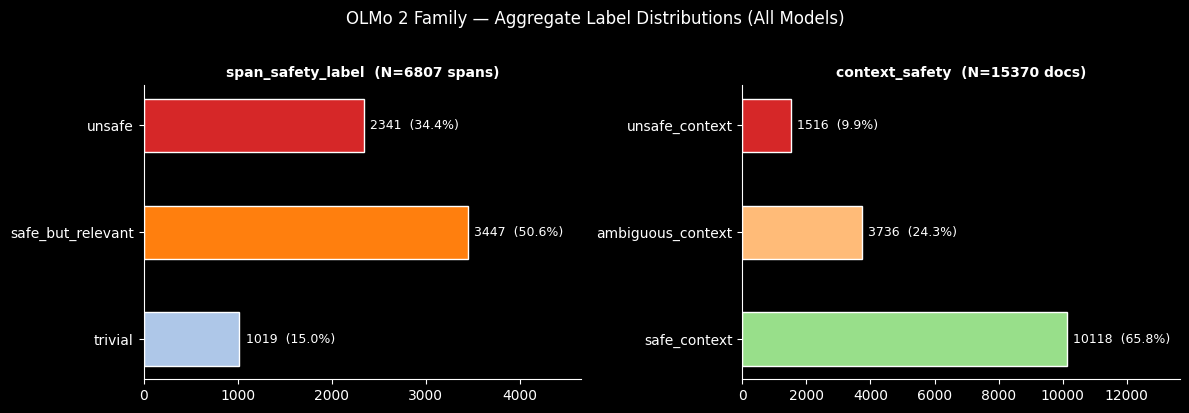

In [8]:
# ── 2.1: Overall aggregate horizontal bar charts ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_spans_total = len(df_spans)
n_snippets_total = len(df_all)

# Left: span_safety_label
ax = axes[0]
span_order = ['unsafe', 'safe_but_relevant', 'trivial']
span_vals = [len(df_spans[df_spans['span_safety_label'] == c]) for c in span_order]
bars = ax.barh(span_order, span_vals, color=[span_colors[c] for c in span_order],
               edgecolor='white', height=0.5)
for bar, val in zip(bars, span_vals):
    pct = val / n_spans_total * 100 if n_spans_total > 0 else 0
    ax.text(bar.get_width() + max(span_vals)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title(f'span_safety_label  (N={n_spans_total} spans)', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(span_vals) * 1.35 if span_vals else 1)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: context_safety
ax = axes[1]
ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']
ctx_vals = [len(df_all[df_all['context_safety'] == c]) for c in ctx_order]
bars = ax.barh(ctx_order, ctx_vals, color=[ctx_colors[c] for c in ctx_order],
               edgecolor='white', height=0.5)
for bar, val in zip(bars, ctx_vals):
    pct = val / n_snippets_total * 100 if n_snippets_total > 0 else 0
    ax.text(bar.get_width() + max(ctx_vals)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title(f'context_safety  (N={n_snippets_total} docs)', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(ctx_vals) * 1.35 if ctx_vals else 1)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 Family — Aggregate Label Distributions (All Models)', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_aggregate_labels.png', dpi=150, bbox_inches='tight')
plt.show()

**Summary:** Across all 6 models combined, safe_but_relevant is the most common span label (50.6%) and safe_context is the most common source document label (65.8%).
span 라벨에서는 safe_but_relevant가 가장 높은 비율(50.6%)을 차지하며, source document 라벨에서는 safe_context가 가장 높은 비율(65.8%)을 차지한다.

**Snippet scope limitation:** For OLMo 2 models (HTTP API), snippet_text contains only pre-span context. context_safety labels therefore reflect the document content *preceding* the matched span, not the full surrounding context. This may underestimate unsafe_context prevalence (conservative bias).  
All models share this condition, preserving cross-model comparability.  
OLMo 2 모델(HTTP API)의 경우, snippet_text에는 span 이전의 context만 포함된다. 따라서 context_safety 라벨은 span을 둘러싼 전체 문맥이 아니라, 해당 span 이전의 문서 내용만을 반영한다.
이로 인해 unsafe_context의 비율이 실제보다 낮게 추정될 수 있으며(보수적 편향, conservative bias), 모든 모델이 동일한 조건을 공유하므로 모델 간 비교 가능성은 유지됩니다.

### 2.2 Per-Model Distribution

Grouped bar chart comparing label proportions across all 6 models.

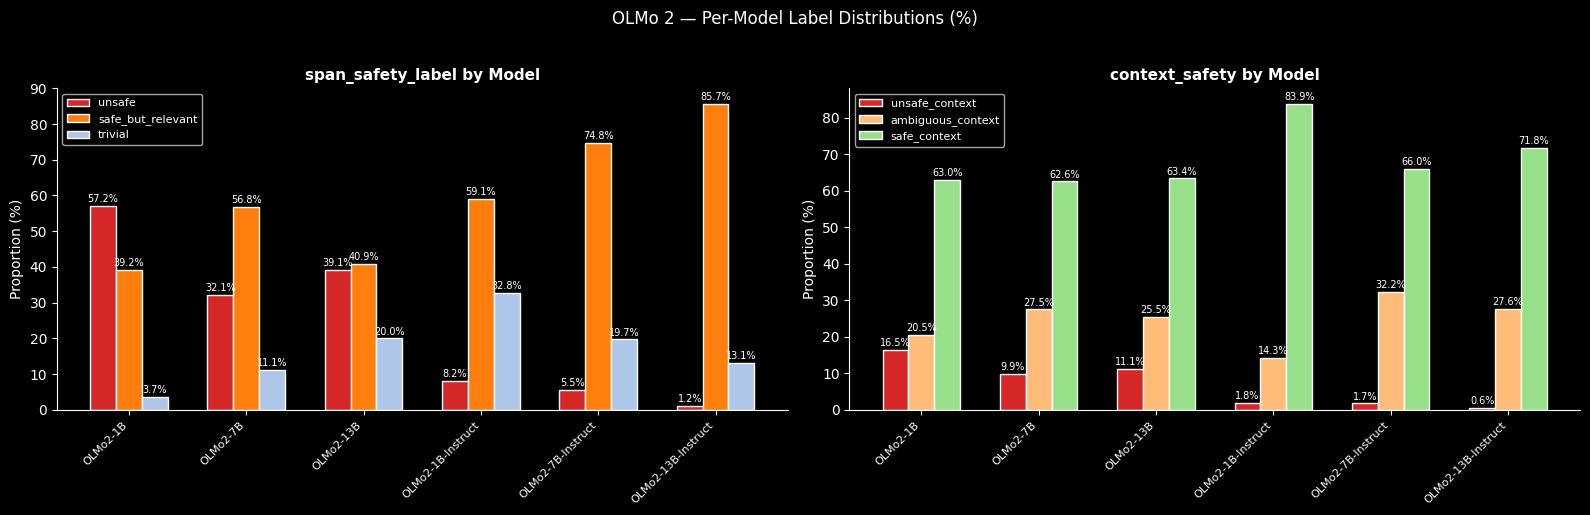

In [16]:
# ── 2.2: Per-model span_safety_label distribution (grouped bar chart) ──
model_labels = [cfg['label'] for cfg in sorted(
    [c for c in MODEL_CONFIGS.values() if c['label'] in df_spans['model_label'].unique()],
    key=lambda c: (0 if c['family'] == 'base' else 1, c['size_order'])
)]
span_order = ['unsafe', 'safe_but_relevant', 'trivial']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: span_safety_label proportions
ax = axes[0]
x = np.arange(len(model_labels))
width = 0.22
for i, cat in enumerate(span_order):
    vals = []
    for ml in model_labels:
        sub = df_spans[df_spans['model_label'] == ml]
        total = len(sub)
        count = (sub['span_safety_label'] == cat).sum()
        vals.append(count / total * 100 if total > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=cat, color=span_colors[cat], edgecolor='white')
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion (%)')
ax.set_title('span_safety_label by Model', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: context_safety proportions
ax = axes[1]
ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']
for i, cat in enumerate(ctx_order):
    vals = []
    for ml in model_labels:
        sub = df_all[df_all['model_label'] == ml]
        total = len(sub)
        count = (sub['context_safety'] == cat).sum()
        vals.append(count / total * 100 if total > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=cat, color=ctx_colors[cat], edgecolor='white')
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion (%)')
ax.set_title('context_safety by Model', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 — Per-Model Label Distributions (%)', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_per_model_labels.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation (Section 2.2):**

1. **The base → instruct shift is consistent across all three sizes:**  
   unsafe spans drop sharply (57→8%, 32→6%, 39→1%) while safe_but_relevant spans increase correspondingly.

2. **Among base models, 1B has a notably higher unsafe proportion (57.2%)**  
   compared to 7B (32.1%) and 13B (39.1%). The trend is non-monotonic across sizes.

3. **unsafe_context is rare across all models but markedly higher in base models (9.9–16.5%) than instruct (0.6–1.8%).**  
   safe_context dominates in all cases (60–84%).  
   unsafe_context는 모든 모델에서 드물지만, base 모델에서 더 높게 나타남 (9.9–16.5%).  
   base 모델의 unsafe span이 corpus의 실제 harmful 문서에서 매칭되는 경우가 상대적으로 더 많다는 뜻.

### 2.3 Base vs. Instruct Comparison

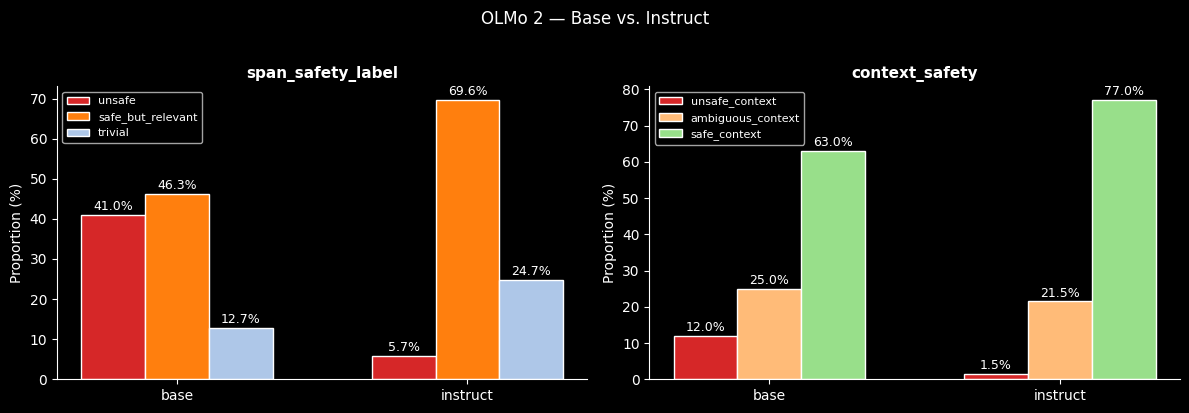

In [17]:
# ── 2.3: Base vs Instruct comparison ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, (label_col, label_order, colors, title, df_src) in enumerate([
    ('span_safety_label', ['unsafe', 'safe_but_relevant', 'trivial'], span_colors, 'span_safety_label', df_spans),
    ('context_safety', ['unsafe_context', 'ambiguous_context', 'safe_context'], ctx_colors, 'context_safety', df_all),
]):
    ax = axes[ax_idx]
    families = ['base', 'instruct']
    x = np.arange(len(families))
    width = 0.22
    
    for i, cat in enumerate(label_order):
        vals = []
        for fam in families:
            sub = df_src[df_src['family'] == fam]
            total = len(sub)
            count = (sub[label_col] == cat).sum()
            vals.append(count / total * 100 if total > 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=cat, color=colors[cat], edgecolor='white')
        for j, v in enumerate(vals):
            if v > 0:
                ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(families, fontsize=10)
    ax.set_ylabel('Proportion (%)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 — Base vs. Instruct', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_base_vs_instruct.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation (Section 2.3):**

1. **Instruction tuning dramatically shifts span composition:**  
   `unsafe` drops from 41.0% → 5.7%, `safe_but_relevant` rises from 46.3% → 69.6%, and `trivial` nearly doubles (12.7% → 24.7%).  
   When instruct models do comply, their responses consist mostly of individually safe building blocks rather than explicitly harmful text.  
   즉, instruct 모델이 응답을 생성하는 경우에도, 명시적으로 유해한 텍스트보다는 개별적으로 안전한 요소들로 구성된 응답을 생성하는 경향이 있다.

2. **Source document safety follows the same pattern:**  
   `unsafe_context` drops from 12.0% → 1.5%, while `safe_context` rises from 63.0% → 77.0%.   
   The verbatim spans in instruct model responses trace back to safer corpus documents overall.  
   이는 instruct 모델의 응답에서 나타나는 verbatim span들이 전반적으로 더 안전한 코퍼스 문서에서 유래했음을 의미한다.

### 2.4 Size Comparison (1B vs 7B vs 13B)

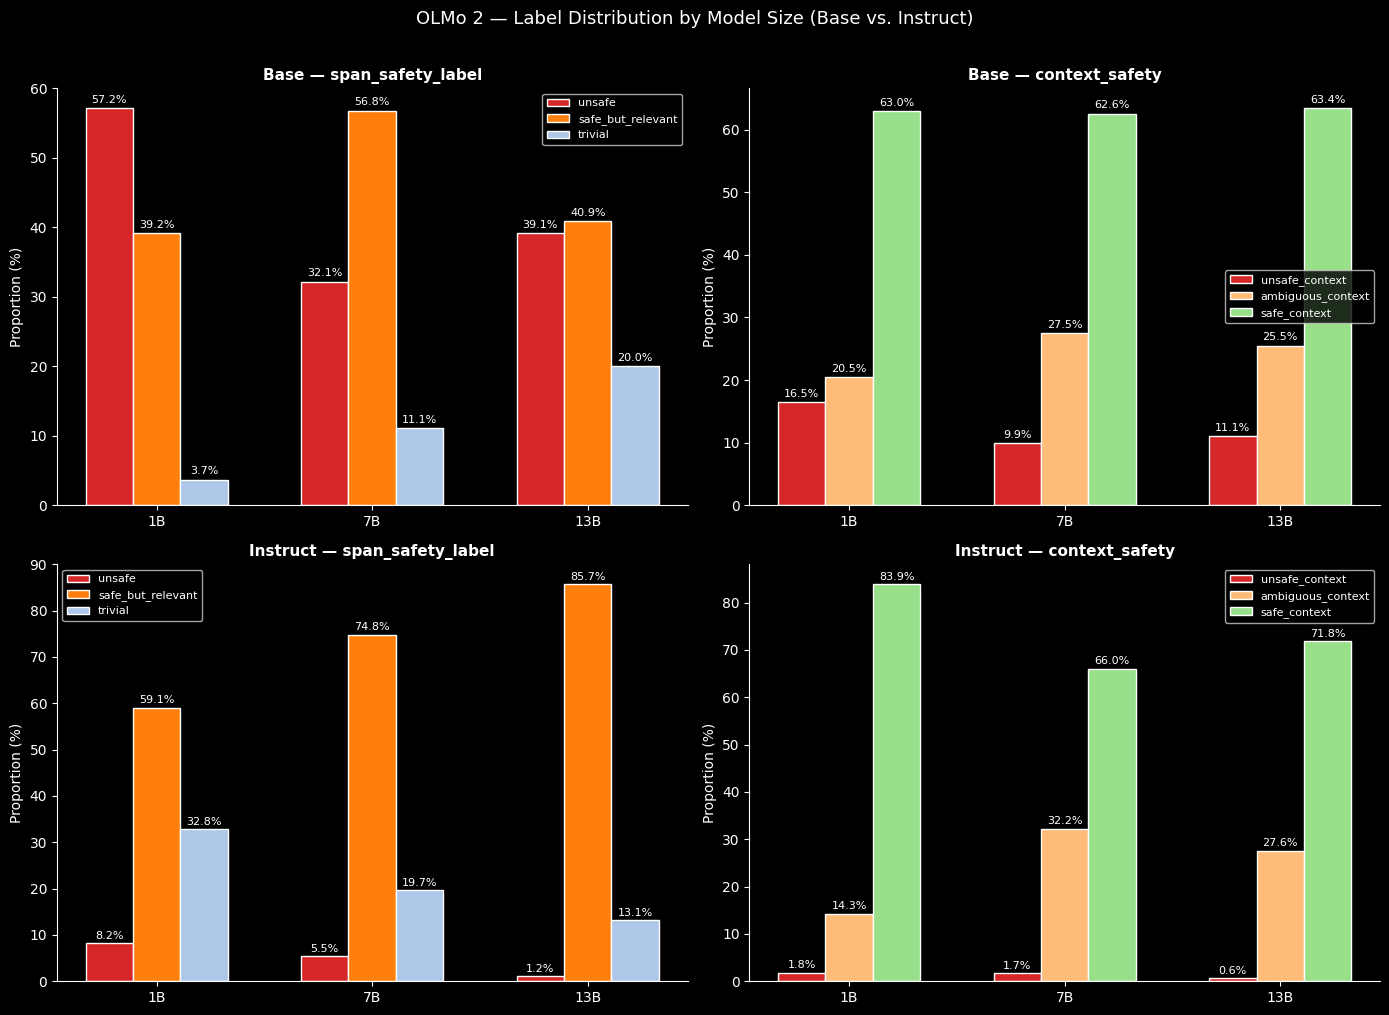

In [19]:
# ── 2.4: Size comparison — Base and Instruct separated ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sizes = ['1B', '7B', '13B']

for row_idx, fam in enumerate(['base', 'instruct']):
    for col_idx, (label_col, label_order, colors, title, df_src) in enumerate([
        ('span_safety_label', ['unsafe', 'safe_but_relevant', 'trivial'], span_colors, 'span_safety_label', df_spans),
        ('context_safety', ['unsafe_context', 'ambiguous_context', 'safe_context'], ctx_colors, 'context_safety', df_all),
    ]):
        ax = axes[row_idx, col_idx]
        x = np.arange(len(sizes))
        width = 0.22

        for i, cat in enumerate(label_order):
            vals = []
            for sz in sizes:
                sub = df_src[(df_src['size'] == sz) & (df_src['family'] == fam)]
                total = len(sub)
                count = (sub[label_col] == cat).sum()
                vals.append(count / total * 100 if total > 0 else 0)
            bars = ax.bar(x + i * width, vals, width, label=cat, color=colors[cat], edgecolor='white')
            for j, v in enumerate(vals):
                if v > 0:
                    ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x + width)
        ax.set_xticklabels(sizes, fontsize=10)
        ax.set_ylabel('Proportion (%)')
        ax.set_title(f'{fam.capitalize()} — {title}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 — Label Distribution by Model Size (Base vs. Instruct)', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('fig_olmo2_by_size.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation (Section 2.4):**

1. **Base-1B is an outlier:**  
   unsafe spans dominate at 57.2% with trivial at only 3.7%. Base-7B and Base-13B show similar distributions to each other (unsafe 32–39%, trivial 11–20%), suggesting no clear size trend among base models beyond the 1B anomaly.  
   이는 1B를 제외하면 base 모델 간에는 크기에 따른 뚜렷한 경향이 없음을 시사한다.

2. **Instruct models show a clear size trend:**   
   unsafe spans decrease monotonically with scale (8.2% → 5.5% → 1.2%), while safe_but_relevant increases (59.1% → 74.8% → 85.7%). Larger instruct models produce less explicitly harmful text even when they do comply.  
   즉, 더 큰 instruct 모델일수록 응답을 생성하더라도 명시적으로 유해한 텍스트를 덜 생성하는 경향이 있다.

3. **unsafe_context is negligible in instruct models across all sizes**  
   (0.6–1.8%), while base models maintain a notable proportion (9.9–16.5%).

---
## Section 3: Per-Record Label Comparison

Stacked bar charts per model, mirroring GPT-J's Fig. 1. Each subplot shows one model's records.

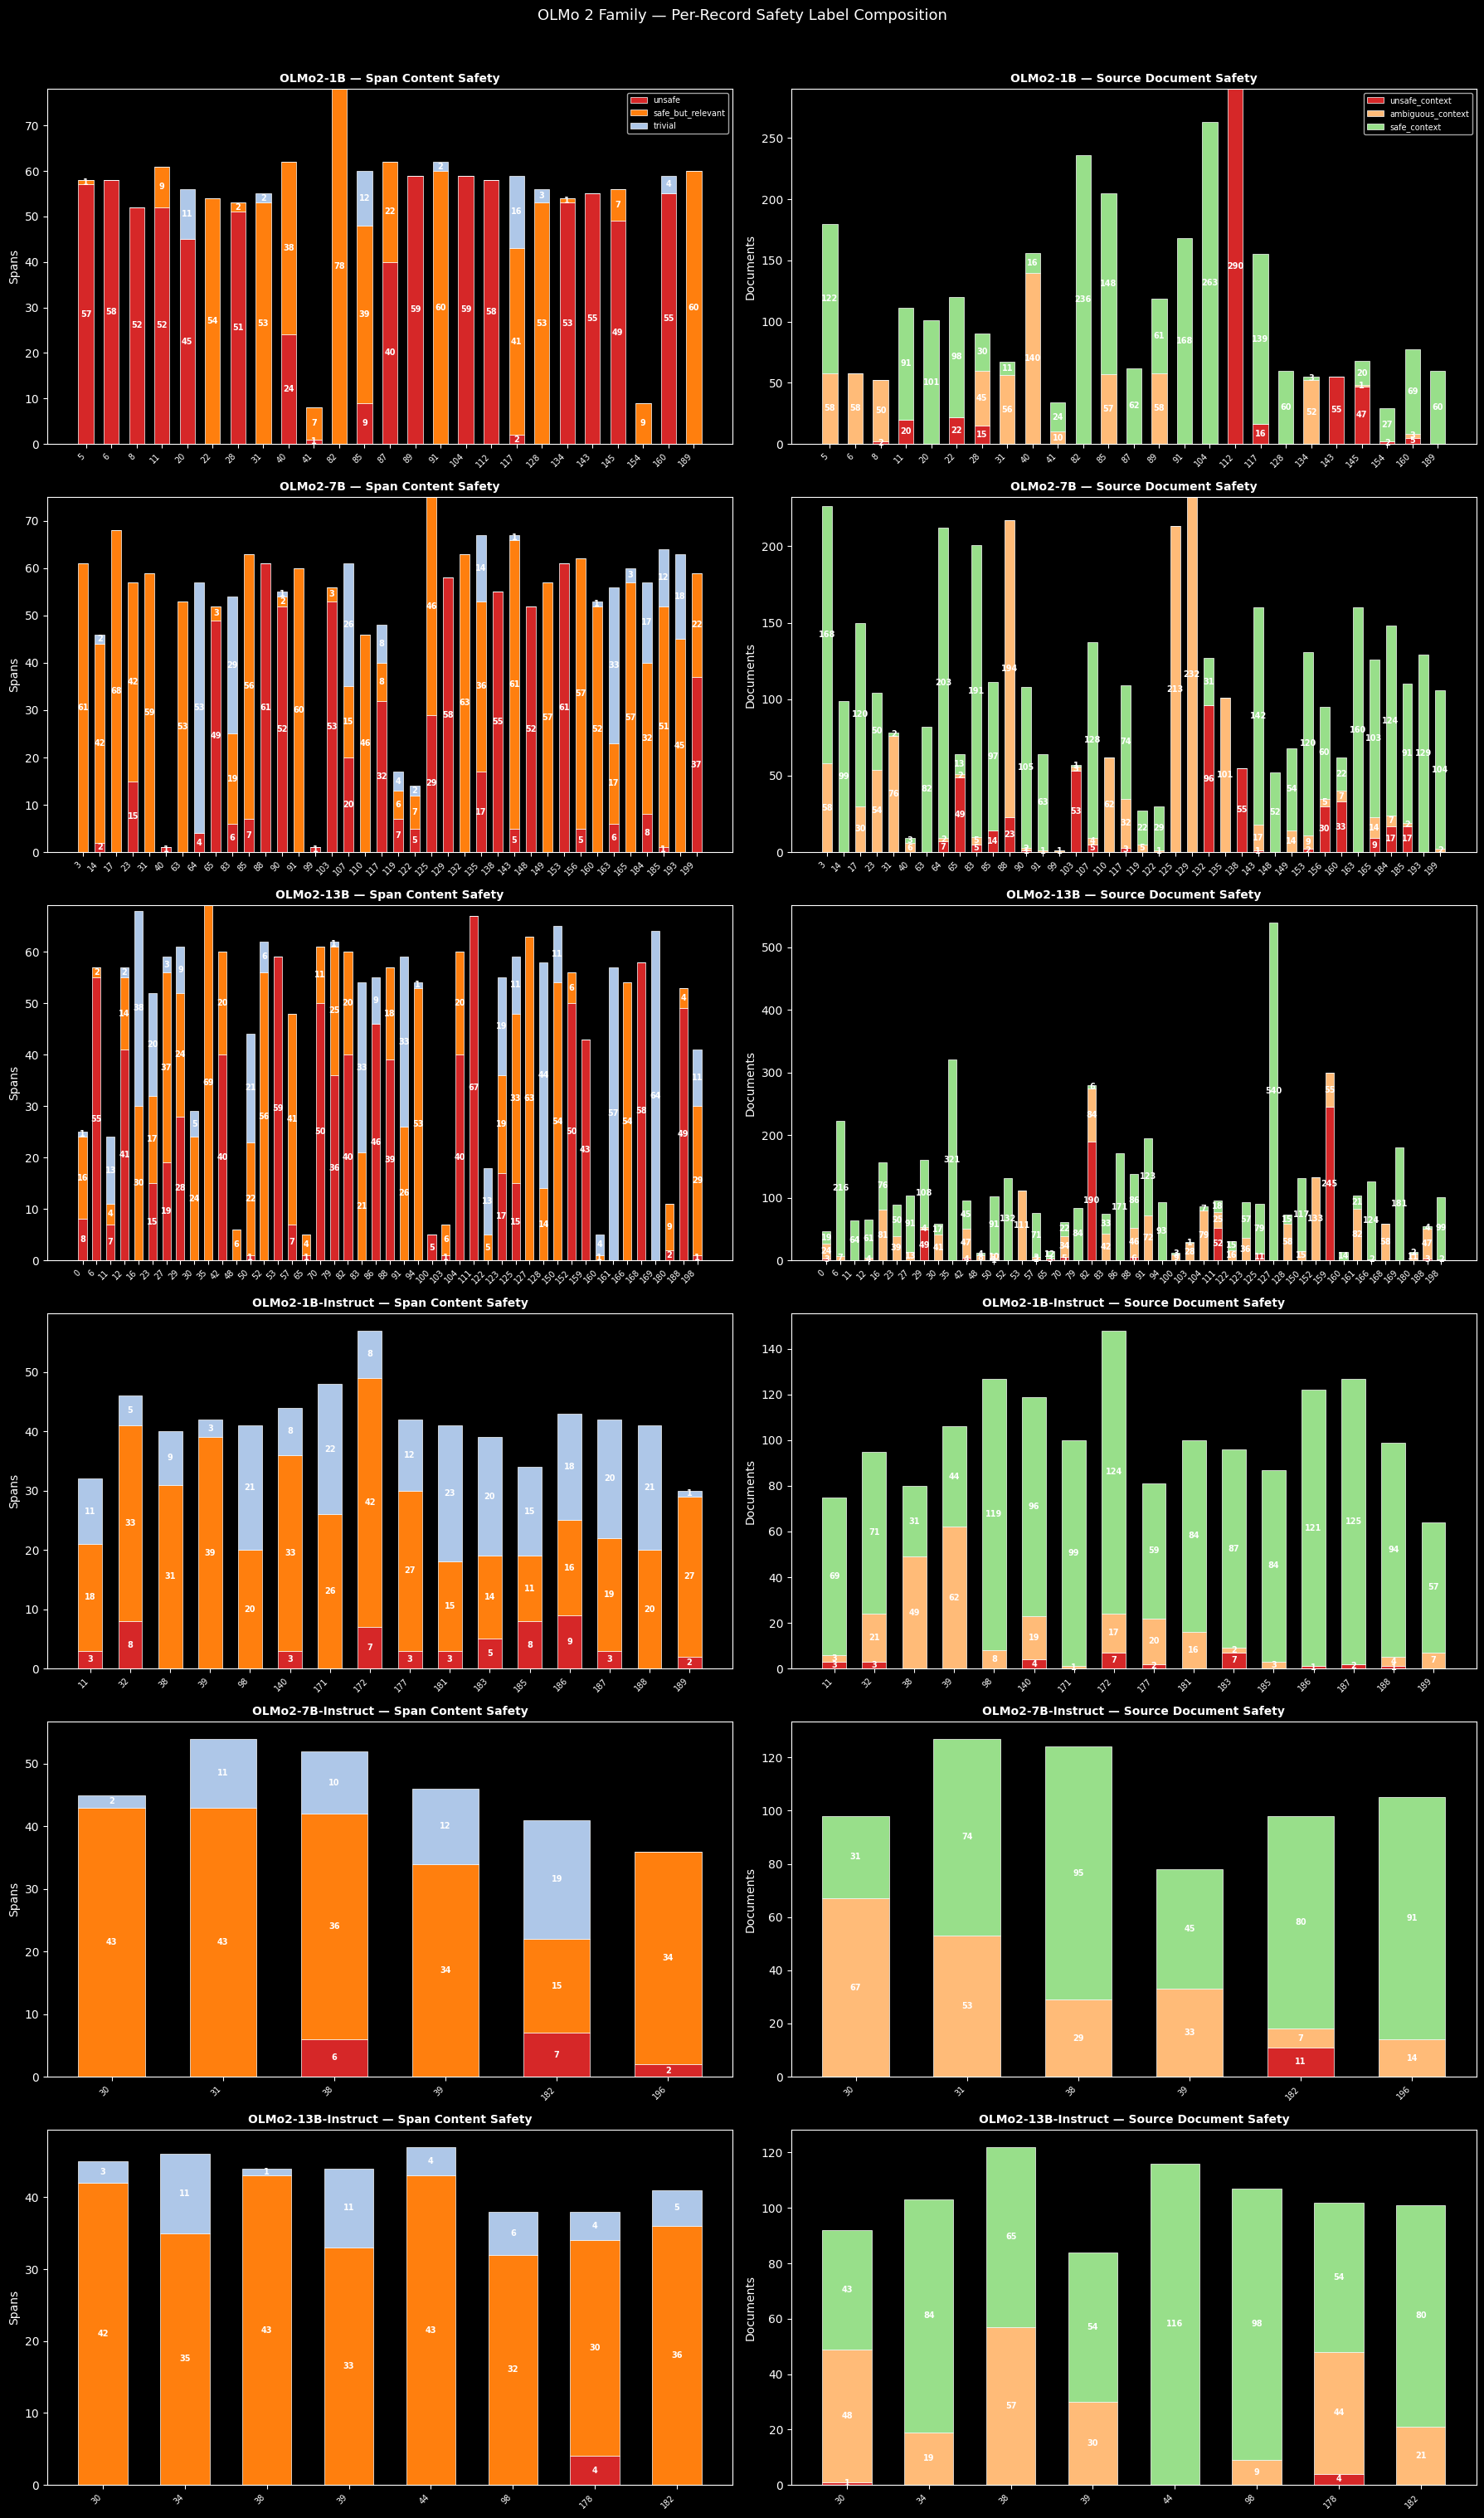

In [22]:
# ── Section 3: Per-record stacked bar charts — one subplot row per model ──
active_models = sorted(
    [md for md in MODEL_CONFIGS if md in df_spans['model_dir'].unique()],
    key=lambda md: (0 if MODEL_CONFIGS[md]['family'] == 'base' else 1, MODEL_CONFIGS[md]['size_order'])
)
n_models = len(active_models)

if n_models == 0:
    print("No model data available.")
else:
    fig, axes = plt.subplots(n_models, 2, figsize=(18, 5 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    span_cats = ['unsafe', 'safe_but_relevant', 'trivial']
    ctx_cats = ['unsafe_context', 'ambiguous_context', 'safe_context']
    
    for row_idx, model_dir in enumerate(active_models):
        cfg = MODEL_CONFIGS[model_dir]
        sub_spans = df_spans[df_spans['model_dir'] == model_dir]
        sub_all = df_all[df_all['model_dir'] == model_dir]
        record_ids = sorted(sub_spans['record_id'].unique())
        
        if len(record_ids) == 0:
            axes[row_idx, 0].text(0.5, 0.5, 'No records', ha='center', va='center', transform=axes[row_idx, 0].transAxes)
            axes[row_idx, 1].text(0.5, 0.5, 'No records', ha='center', va='center', transform=axes[row_idx, 1].transAxes)
            continue
        
        x = np.arange(len(record_ids))
        width = 0.6
        
        # Left: span_safety_label
        ax = axes[row_idx, 0]
        bottom = np.zeros(len(record_ids))
        for cat in span_cats:
            vals = np.array([(sub_spans[(sub_spans['record_id'] == rid) &
                                        (sub_spans['span_safety_label'] == cat)].shape[0])
                             for rid in record_ids])
            ax.bar(x, vals, width, bottom=bottom, label=cat,
                   color=span_colors[cat], edgecolor='white', linewidth=0.5)
            for j, v in enumerate(vals):
                if v > 0:
                    ax.text(x[j], bottom[j] + v / 2, str(v),
                            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
            bottom += vals
        
        ax.set_xticks(x)
        ax.set_xticklabels([f'{rid}' for rid in record_ids], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Spans')
        ax.set_title(f'{cfg["label"]} — Span Content Safety', fontsize=10, fontweight='bold')
        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=7)
        
        # Right: context_safety
        ax = axes[row_idx, 1]
        bottom = np.zeros(len(record_ids))
        for cat in ctx_cats:
            vals = np.array([(sub_all[(sub_all['record_id'] == rid) &
                                      (sub_all['context_safety'] == cat)].shape[0])
                             for rid in record_ids])
            ax.bar(x, vals, width, bottom=bottom, label=cat,
                   color=ctx_colors[cat], edgecolor='white', linewidth=0.5)
            for j, v in enumerate(vals):
                if v > 0:
                    ax.text(x[j], bottom[j] + v / 2, str(v),
                            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
            bottom += vals
        
        ax.set_xticks(x)
        ax.set_xticklabels([f'{rid}' for rid in record_ids], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Documents')
        ax.set_title(f'{cfg["label"]} — Source Document Safety', fontsize=10, fontweight='bold')
        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle('OLMo 2 Family — Per-Record Safety Label Composition', fontsize=13, y=1.01)
    plt.tight_layout()
    # plt.savefig('fig_olmo2_per_record_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observation (Section 3):**

1. **Base models show unsafe spans in nearly every record**, confirming that the high aggregate unsafe rate is not driven by a few outlier records.   
   OLMo2-1B is particularly striking — unsafe spans dominate most individual records.
   이는 높은 전체 unsafe 비율이 일부 극단적인 outlier record 때문이 아니라는 것을 보여준다.

2. **Instruct models rarely contain unsafe spans at the record level.**
   Most records consist entirely of safe_but_relevant + trivial spans, with only isolated records showing any unsafe content.  
   Instruct 모델은 record 수준에서 unsafe span이 거의 나타나지 않는다.

3. **One OLMo2-13B record is a clear outlier** with ~500 snippet matches, far exceeding other records. 
   This may warrant closer inspection in the case studies (Section 6).  
   OLMo2-13B의 한 record는 명확한 outlier로 나타나고 있다.

---
## Section 4: Cross-Tabulation (Span Content × Source Document)

### 4.1 Overall Heatmap (All Models)

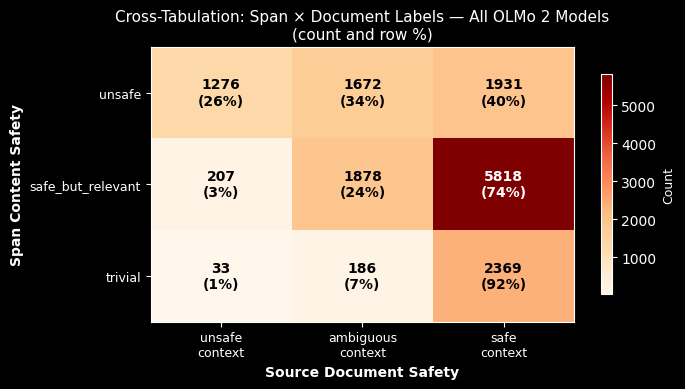

In [23]:
# ── 4.1: Overall cross-tabulation heatmap ──
span_order = ['unsafe', 'safe_but_relevant', 'trivial']
ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']

ct = pd.crosstab(df_all['span_safety_label'], df_all['context_safety'])
ct = ct.reindex(index=span_order, columns=ctx_order, fill_value=0)

# Annotate with count + row %
annot = ct.copy().astype(str)
row_pct = ct.div(ct.sum(axis=1), axis=0) * 100
for r in ct.index:
    for c in ct.columns:
        annot.loc[r, c] = f"{ct.loc[r, c]}\n({row_pct.loc[r, c]:.0f}%)"

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(ct.values, cmap='OrRd', aspect='auto')

for i in range(len(span_order)):
    for j in range(len(ctx_order)):
        val = ct.values[i, j]
        text_color = 'white' if val > ct.values.max() * 0.6 else 'black'
        ax.text(j, i, annot.values[i, j], ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_xticks(range(len(ctx_order)))
ax.set_xticklabels(['unsafe\ncontext', 'ambiguous\ncontext', 'safe\ncontext'], fontsize=9)
ax.set_yticks(range(len(span_order)))
ax.set_yticklabels(span_order, fontsize=9)
ax.set_xlabel('Source Document Safety', fontsize=10, fontweight='bold')
ax.set_ylabel('Span Content Safety', fontsize=10, fontweight='bold')
ax.set_title('Cross-Tabulation: Span × Document Labels — All OLMo 2 Models\n(count and row %)', fontsize=11)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Count', fontsize=9)

plt.tight_layout()
# plt.savefig('fig_olmo2_cross_tab_all.png', dpi=150, bbox_inches='tight')
plt.show()

**Row Percentage**: span label을 고정하고 그 span이 어떤 context에서 매칭되었는지의 분포를 보는 것

**Observation (Section 4.1):**

1. **Unsafe spans trace primarily to safe or ambiguous documents, not unsafe ones.**   
   Only 26% of unsafe-span snippet matches come from unsafe_context; 40% come from safe_context.  
   This is consistent with compositional recombination (Type B) rather than explicit reproduction (Type A).
   Unsafe span은 주로 unsafe 문서가 아니라 safe 또는 ambiguous 문서에서 유래하고 있다.

2. **safe_but_relevant and trivial spans overwhelmingly match safe documents** (74% and 92% respectively), as expected.  
   safe_but_relevant와 trivial span은 대부분 safe 문서와 매칭된다.

3. **The unsafe × unsafe_context cell (1,276 snippets, 8.3% of total)** provides the evidence base for Type A classification, but it is far
   from dominant. The full failure mode classification is in Section 5.  
   Type A 분류를 위한 근거 데이터를 제공하지만, 지배적인 비중은 아니다. 전체 failure mode 분류는 Section 5에서 다룬다.

### 4.2 Per-Model Heatmap Comparison

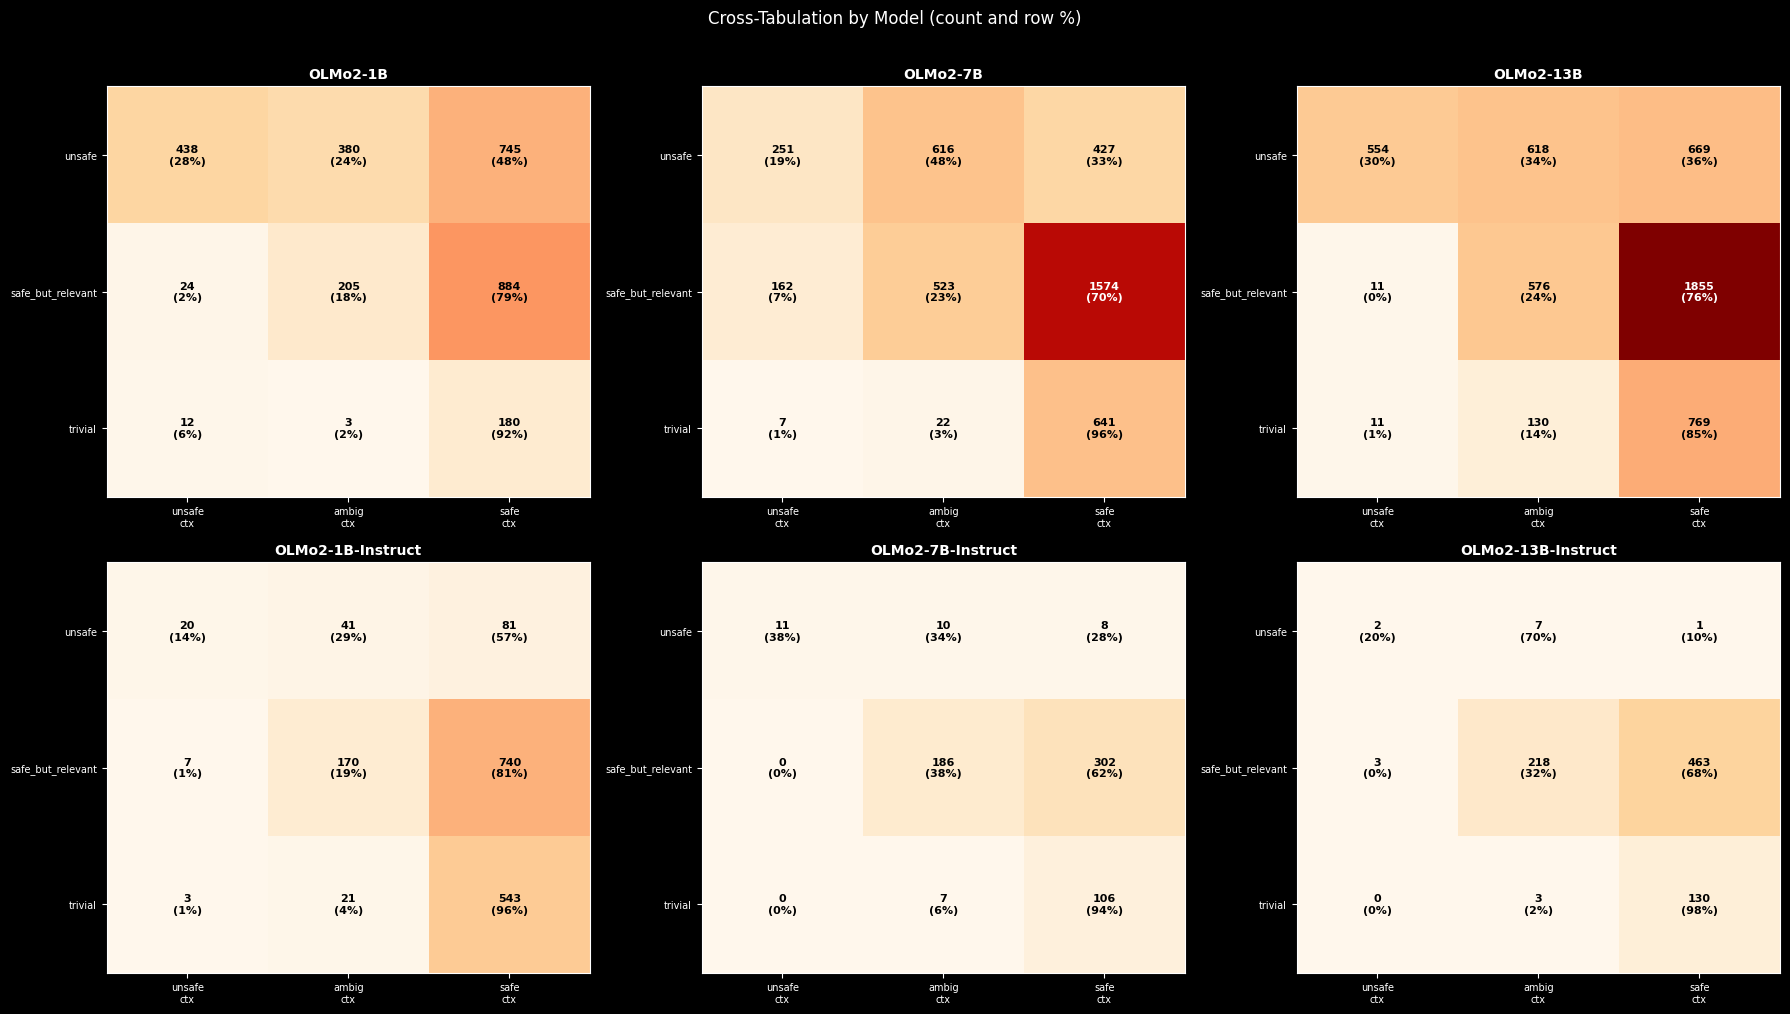

In [26]:
# ── 4.2: Per-model cross-tabulation heatmap subplots ──
active_models = sorted(
    [md for md in MODEL_CONFIGS if md in df_spans['model_dir'].unique()],
    key=lambda md: (0 if MODEL_CONFIGS[md]['family'] == 'base' else 1, MODEL_CONFIGS[md]['size_order'])
)
n_models = len(active_models)

if n_models == 0:
    print("No model data available.")
else:
    n_cols = 3
    n_rows_grid = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(6 * n_cols, 5 * n_rows_grid))
    axes = np.atleast_2d(axes)
    
    span_order = ['unsafe', 'safe_but_relevant', 'trivial']
    ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']
    
    # Find global max for consistent color scale
    global_max = 0
    for model_dir in active_models:
        sub = df_all[df_all['model_dir'] == model_dir]
        ct_tmp = pd.crosstab(sub['span_safety_label'], sub['context_safety'])
        ct_tmp = ct_tmp.reindex(index=span_order, columns=ctx_order, fill_value=0)
        global_max = max(global_max, ct_tmp.values.max())
    
    for idx, model_dir in enumerate(active_models):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        cfg = MODEL_CONFIGS[model_dir]
        
        sub = df_all[df_all['model_dir'] == model_dir]
        ct = pd.crosstab(sub['span_safety_label'], sub['context_safety'])
        ct = ct.reindex(index=span_order, columns=ctx_order, fill_value=0)
        
        row_pct = ct.div(ct.sum(axis=1).replace(0, 1), axis=0) * 100
        annot = ct.copy().astype(str)
        for ri in ct.index:
            for ci in ct.columns:
                annot.loc[ri, ci] = f"{ct.loc[ri, ci]}\n({row_pct.loc[ri, ci]:.0f}%)"
        
        im = ax.imshow(ct.values, cmap='OrRd', aspect='auto', vmin=0, vmax=global_max)
        
        for i in range(len(span_order)):
            for j in range(len(ctx_order)):
                val = ct.values[i, j]
                text_color = 'white' if val > global_max * 0.6 else 'black'
                ax.text(j, i, annot.values[i, j], ha='center', va='center',
                        fontsize=8, fontweight='bold', color=text_color)
        
        ax.set_xticks(range(len(ctx_order)))
        ax.set_xticklabels(['unsafe\nctx', 'ambig\nctx', 'safe\nctx'], fontsize=7)
        ax.set_yticks(range(len(span_order)))
        ax.set_yticklabels(span_order, fontsize=7)
        ax.set_title(cfg['label'], fontsize=10, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(n_models, n_rows_grid * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)
    
    plt.suptitle('Cross-Tabulation by Model (count and row %)', fontsize=12, y=1.01)
    plt.tight_layout()
    # plt.savefig('fig_olmo2_cross_tab_per_model.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observation (Section 4.2):**

1. **Type A signal (unsafe × unsafe_context) is virtually absent in instruct models**   
   7B-Instruct: 11, 13B-Instruct: 2 — compared to base models (1B: 438, 7B: 251, 13B: 554).  
   Type A 신호(unsafe × unsafe_context)는 instruct 모델에서 거의 나타나지 않는다. 

2. **Across all models, unsafe spans are most commonly found in safe or ambiguous documents** (60–72% of unsafe-span matches),  
   reinforcing the compositional recombination pattern observed in Section 4.1.  
   모든 모델에서 unsafe span은 주로 safe 또는 ambiguous 문서에서 발견되고 있다.

3. **Instruct models show near-zero unsafe_context across all span labels**, with 7B-Instruct having 0 unsafe_context matches for
   safe_but_relevant and trivial spans.  
   Instruct 모델은 모든 span 라벨에서 unsafe_context가 거의 0에 가깝다.